In [1]:
import pandas as pd
import glob
import os
import warnings

warnings.filterwarnings("ignore")

In [2]:


# Define folder path
folder_path = "units/cume_units.xlsx"


# Read all files into DataFrames and add filename column
df = pd.read_excel(folder_path, skiprows=2)



In [3]:
folder_path = "units/cume_revenues.xlsx"


revs  = pd.read_excel(folder_path, skiprows=2)


In [4]:
folder_path = "wishlists/Annapurna Interactive Historical Revenues - releases_dates.csv"
dates  = pd.read_csv(folder_path)
dates = dates.dropna(subset='pc_release_date')
dates['pc_release_date'] = pd.to_datetime(dates['pc_release_date'])
release_date_dict = dates.groupby('product')['pc_release_date'].min().to_dict()

In [5]:
df.query("product =='Stray'")

,Date,product,Cumulative Selected Measure
35305,2022-06-02,Stray,13946
35353,2022-06-03,Stray,36669
35401,2022-06-04,Stray,51053
35449,2022-06-05,Stray,63298
35497,2022-06-06,Stray,73428
...,...,...,...
98544,2025-05-10,Stray,6501466
98615,2025-05-11,Stray,6502749
98686,2025-05-12,Stray,6503492
98757,2025-05-13,Stray,6504041


In [6]:
revs

,Date,product,Cumulative Selected Measure
0,2017-03-14,What Remains of Edith Finch,2673.49
1,2017-03-15,What Remains of Edith Finch,7086.67
2,2017-03-16,What Remains of Edith Finch,9976.77
3,2017-03-17,What Remains of Edith Finch,11789.20
4,2017-03-18,What Remains of Edith Finch,14156.59
...,...,...,...
98842,2025-05-14,Wanderstop - Soundtrack,16507.44
98843,2025-05-14,Wattam,1068912.92
98844,2025-05-14,Wattam - Original Soundtrack,4861.78
98845,2025-05-14,What Remains of Edith Finch,19636889.05


In [7]:
df = df.rename({"Cumulative Selected Measure":"units"}, axis=1)

In [8]:
df.drop_duplicates(subset='product', keep='last').tail(25)

,Date,product,units
98822,2025-05-14,Skin Deep - Soundtrack Edition,2
98823,2025-05-14,Skin Deep Soundtrack,476
98824,2025-05-14,Solar Ash,116981
98825,2025-05-14,Solar Ash - Original Soundtrack,1104
98826,2025-05-14,Storyteller,571751
98827,2025-05-14,Storyteller - Original Soundtrack,8815
98828,2025-05-14,Stray,6504177
98829,2025-05-14,Stray - Original Soundtrack,79387
98830,2025-05-14,Telling Lies,177650
98831,2025-05-14,Telling Lies - Original Soundtrack,1301


In [9]:
df['release_date'] = pd.to_datetime(df['Date'])

df['release_date'] = df.groupby('product')['release_date'].transform('min')
df['release_date'] = df['product'].map(release_date_dict)

df["DAR"] = (df["Date"] - df["release_date"]).dt.days
#df["DAR"] = df.groupby("product")["DAR"].transform(lambda x: x.clip(lower=0))

df["Weeks_from_Release"] = (df["DAR"] // 7) + 1  # Week 1 starts at 0-7 days

#df = df.query("0 <= Weeks_from_Release <=12")

df = df.query("'1/1/2015' <= release_date <='1/1/2026'")

#df = df.groupby(["product",'Date', "Weeks_from_Release"], as_index=False)["units"].max()
df = df.groupby(["product", "Weeks_from_Release"], as_index=False)["units"].max()

In [10]:
title = ['Stray', 'Outer Wilds', "What Remains of Edith Finch"]

In [11]:
current_cume = df.query("product==@title")['units'].values[-1]
current_week = df.query("product==@title")['Weeks_from_Release'].values[-1]

In [12]:
current_week

421.0

In [13]:
title_df = df.query("product==@title")

In [14]:
stray_custom = pd.read_excel("units/stray_platform.xlsx", skiprows=2)

In [15]:
stray_custom = stray_custom.pivot(columns='portal', index='Date', values="Selected Measure").reset_index()

In [16]:
stray_custom['release_date'] = '7/19/2022'
stray_custom['release_date'] = pd.to_datetime(stray_custom['release_date'])

In [17]:
stray_custom["DAR"] = (stray_custom["Date"] - stray_custom["release_date"]).dt.days
stray_custom["Weeks_from_Release"] = (stray_custom["DAR"] // 7) + 1  # Week 1 starts at 0-7 days


In [18]:
stray_custom = stray_custom[['Weeks_from_Release', 'PlayStation', 'Steam']]

In [19]:
stray_custom['PlayStation'] = stray_custom['PlayStation'].cumsum()
stray_custom['Steam'] = stray_custom['Steam'].cumsum()

In [20]:
title_df.query("product=='Stray'")

,product,Weeks_from_Release,units
5423,Stray,-6.0,73428
5424,Stray,-5.0,113690
5425,Stray,-4.0,135569
5426,Stray,-3.0,159507
5427,Stray,-2.0,186967
...,...,...,...
5573,Stray,144.0,6459059
5574,Stray,145.0,6485633
5575,Stray,146.0,6496010
5576,Stray,147.0,6503492


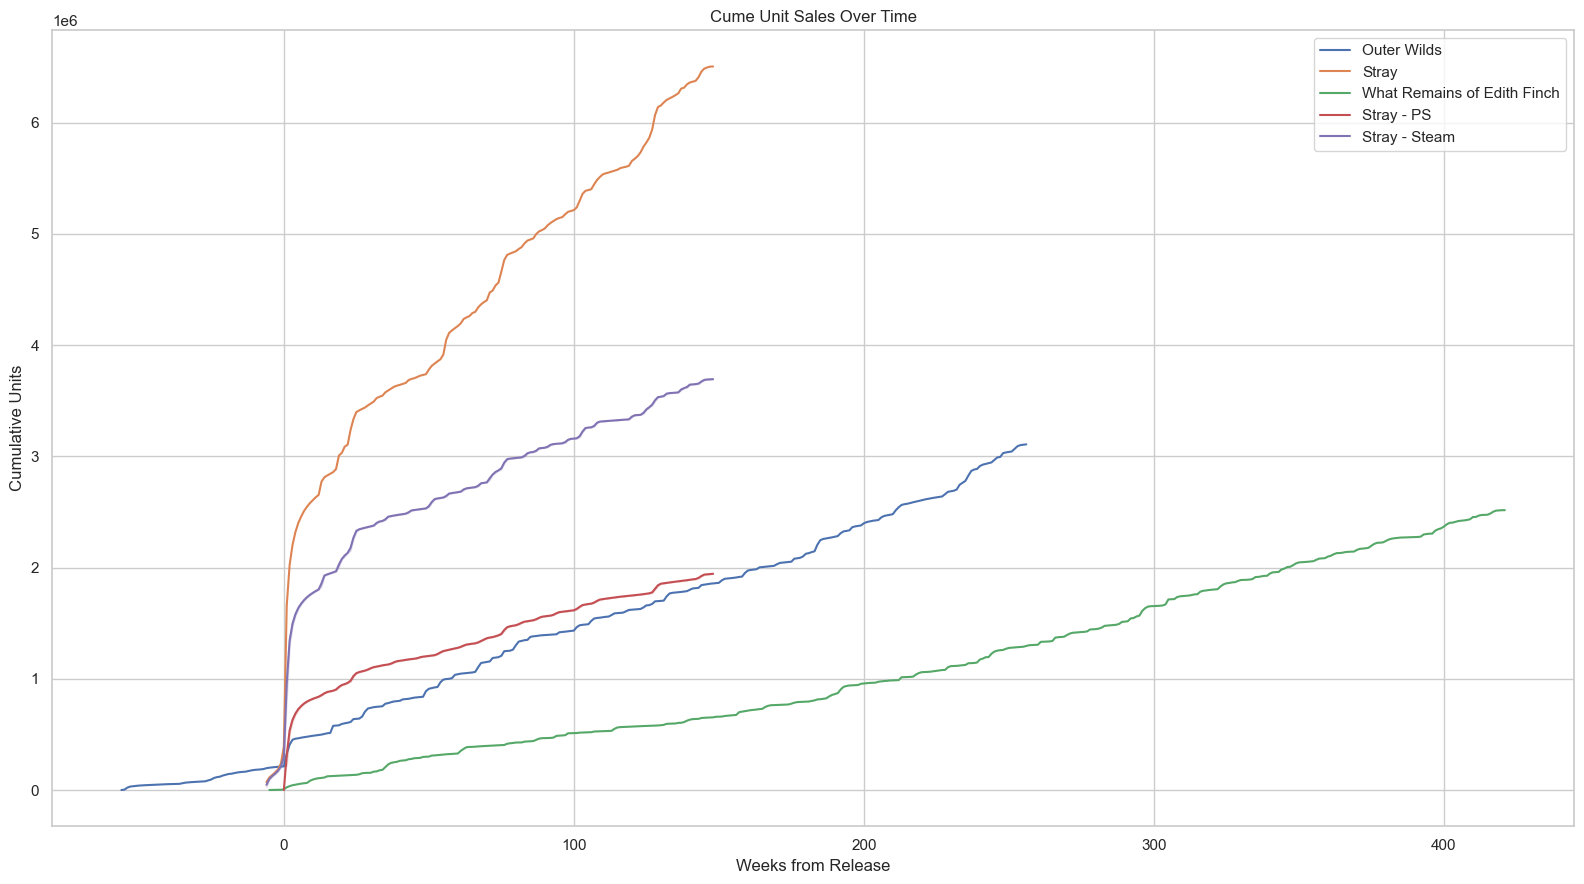

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style for aesthetics
sns.set_theme(style="whitegrid")

# Plot the data
plt.figure(figsize=(16, 9))
sns.lineplot(data=title_df, x="Weeks_from_Release", y="units", hue='product')
sns.lineplot(data=stray_custom, x="Weeks_from_Release", y="PlayStation", label='Stray - PS')
sns.lineplot(data=stray_custom, x="Weeks_from_Release", y="Steam", label='Stray - Steam')


# Adding titles and labels
plt.title("Cume Unit Sales Over Time")
plt.xlabel("Weeks from Release")
plt.ylabel("Cumulative Units")

# Show the plot
plt.tight_layout()
plt.show()

In [22]:
title_df['new_units'] = title_df['units'].diff()

In [23]:
ranked_df = df.query("Weeks_from_Release ==1").sort_values(by='units', ascending=False)

In [24]:
range = 0.50

high_end = current_cume * (1 + range)
low_end = current_cume * (1 - range)

In [25]:
low_end

1258181.0

In [26]:
df_filtered = ranked_df[~ranked_df['product'].str.contains('Soundtrack', case=False, na=False)]


In [27]:
df_filtered.query("@low_end < units <@high_end")

,product,Weeks_from_Release,units
5430,Stray,1.0,1658796


In [28]:
df_filtered['pct_rank'] = df_filtered['units'].rank(pct=True)

In [29]:
df_filtered

,product,Weeks_from_Release,units,pct_rank
5430,Stray,1.0,1658796,1.000000
4575,Outer Wilds,1.0,328805,0.972973
3073,Journey,1.0,210564,0.945946
6632,Twelve Minutes,1.0,100322,0.918919
217,Ashen,1.0,90201,0.891892
6124,The Pathless,1.0,79850,0.864865
4307,Neon White,1.0,57366,0.837838
5184,Solar Ash,1.0,53134,0.810811
4843,Sayonara Wild Hearts,1.0,43695,0.783784
956,Due Process,1.0,41731,0.756757


In [30]:
df_filtered.query("product==@title")

,product,Weeks_from_Release,units,pct_rank
5430,Stray,1.0,1658796,1.000000
4575,Outer Wilds,1.0,328805,0.972973
7131,What Remains of Edith Finch,1.0,25527,0.567568


In [31]:
stop

NameError: name 'stop' is not defined

# Average Sales Price

In [ ]:


# Define folder path
folder_path = "units/cume_units.xlsx"


# Read all files into DataFrames and add filename column
units = pd.read_excel(folder_path, skiprows=2)

units = units.rename({"Cumulative Selected Measure":"units"}, axis=1)

In [ ]:
units

In [ ]:

revs = revs.rename({"Cumulative Selected Measure":"revenue"}, axis=1)

revs

In [ ]:
combined = pd.merge(units, revs, on=["product", 'Date'])

In [ ]:
combined['avg_price'] = combined['revenue'] / combined['units']

In [ ]:
combined.query("product=='Stray'")

In [ ]:
combined.groupby(by='product')[['units', 'revenue', 'avg_price']].max().to_csv("lifetime_units_and_rev.csv")

In [ ]:
combined['release_date'] = pd.to_datetime(combined['Date'])

combined['release_date'] = combined.groupby('product')['release_date'].transform('min')

combined["DAR"] = (combined["Date"] - combined["release_date"]).dt.days
#df_combined["DAR"] = df_combined["DAR"].clip(lower=0)

combined["Weeks_from_Release"] = (combined["DAR"] // 30) + 1  # Week 1 starts at 0-7 days

#df = df.query("0 <= Weeks_from_Release <=12")

combined = combined.query("'1/1/2015' <= release_date <='1/1/2025'")

combined = combined.groupby(["product", "Weeks_from_Release"], as_index=False)["avg_price"].max()

In [ ]:
combined['price_delta'] = combined.groupby('product')['avg_price'].diff()

In [ ]:
import numpy as np

conditions = [
    (combined['Weeks_from_Release'] > 0) & (combined['Weeks_from_Release'] <= 12),   # 1-12 months (first year)
    (combined['Weeks_from_Release'] > 12) & (combined['Weeks_from_Release'] <= 24), # 13-24 months (second year)
    (combined['Weeks_from_Release'] > 24)  # 24+ months (3+ years)
]

choices = ['First Year', 'Second Year', '3+ Years']

combined['TIER'] = np.select(conditions, choices, default='Unknown')  # 'Unknown' if it doesn't fit any condition

In [ ]:
combined.groupby('TIER').avg_price.mean().sort_values()

In [ ]:
combined.groupby('TIER').price_delta.mean().sort_values()